# Pink AI 2026: malignant vs benign from FNA measurements

**Pipeline:** load → clean context columns → parse numbers → cell repairs → **structural repairs** (geometry) → duplicates and label conflicts → leakage audit → model (patient-grouped CV) → **threshold under stress** → submission → evidence sheet.

Rules this notebook follows:
* Every repair parameter (medians, sister-column regressions, geometric constants) is learned on **train only** and then applied to test.
* The test set is never used to fit anything or to choose the threshold. It is only transformed and scored at the very end.
* Every number in the evidence sheet comes from the `EV` dictionary filled in by this notebook (last cell).

Runs top to bottom in about 1–2 minutes with pandas, numpy, scikit-learn and matplotlib only.

In [1]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.isotonic import IsotonicRegression

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)

TEAM = 'Relax Team'      # team name (shown on the evidence sheet)
TEAM_MEMBERS = ['Yousef Shabib', 'Ahmad Irshaid', 'Sarah Alzaro']
TEAM_FILE = re.sub(r'\W+', '', TEAM)   # file-safe version: RelaxTeam
SUBMISSION_N = 1
SEED = 42
TRAIN_PATH, TEST_PATH, SAMPLE_PATH = 'pinkai_train.csv', 'pinkai_test.csv', 'sample_submission.csv'

EV = {}                  # every number quoted in the evidence sheet is stored here

## 1. Load the raw exports
Both files start with a two-line banner (`Pink AI 2026 - Diagnostic Cytology Export`), so we locate the real header row instead of trusting line 1.

In [2]:
def read_export(path):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()
    hdr = next(i for i, l in enumerate(lines) if l.lower().startswith('patient_id'))
    return pd.read_csv(path, skiprows=hdr, dtype=str)

raw_tr, raw_te = read_export(TRAIN_PATH), read_export(TEST_PATH)
sample = pd.read_csv(SAMPLE_PATH, dtype=str)

def norm_col(c):
    return re.sub(r'\s+', '_', c.strip().lower())

renamed = [c for c in raw_tr.columns if norm_col(c) != c]
raw_tr.columns = [norm_col(c) for c in raw_tr.columns]
raw_te.columns = [norm_col(c) for c in raw_te.columns]

MEAS  = ['radius','texture','perimeter','area','smoothness','compactness','concavity',
         'concave_points','symmetry','fractal_dimension']
STATS = ['mean','se','worst']
NUM   = [f'{m}_{s}' for s in STATS for m in MEAS]
assert all(c in raw_tr.columns for c in NUM) and all(c in raw_te.columns for c in NUM)

EV['n_train_rows'], EV['n_test_rows'] = len(raw_tr), len(raw_te)
EV['n_renamed_cols'] = len(renamed)
print('train', raw_tr.shape, '| test', raw_te.shape, '| sample', sample.shape)
print('inconsistent column names fixed:', renamed)

train (9000, 38) | test (3000, 37) | sample (2884, 3)
inconsistent column names fixed: ['Texture_Mean', 'perimeter mean', 'concave points_se', 'AREA_WORST']


## 2. Context columns: IDs, labels, centre, age, dates, notes

In [3]:
def norm_id(s):
    s = str(s).strip()                         # tabs and spaces
    s = re.sub(r'^ID-', '', s).replace(',', '') # 'ID-845611', '84,6497'
    return s[:-2] if s.endswith('.0') else s    # '842138.0'

def norm_label(s):
    return {'m':'M','malignant':'M','1':'M','b':'B','benign':'B','0':'B'}.get(str(s).strip().lower(), np.nan)

def parse_date(s):
    s = str(s).strip()
    for fmt in ('%Y-%m-%d', '%d/%m/%Y', '%d-%b-%y', '%B %d, %Y'):
        try: return pd.to_datetime(s, format=fmt)
        except ValueError: pass
    m = re.fullmatch(r'(\d{4})-(\d{2})-(\d{2})', s)   # '2025-13-02': day and month transposed
    if m and int(m.group(2)) > 12:
        try: return pd.Timestamp(int(m.group(1)), int(m.group(3)), int(m.group(2)))
        except ValueError: pass
    return pd.NaT                                     # '2026-02-30', '31/04/2026' ...

def fix_mojibake(s):
    # UTF-8 text that was decoded as cp1252 ('Ø¹ÙŠÙ†Ø©' -> 'عينة', 'stainâ€™s' -> 'stain’s')
    if pd.isna(s) or not re.search('[ÃØÙâ]', s): return s
    try:
        return b''.join(ch.encode('cp1252') if ch not in '\x81\x8d\x8f\x90\x9d' else ch.encode('latin-1')
                        for ch in s).decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

def clean_context(raw):
    d = pd.DataFrame(index=raw.index)
    d['patient_id'] = raw['patient_id'].map(norm_id)
    d['center'] = raw['center'].str.strip().str.title()
    age = pd.to_numeric(raw['age'].str.strip(), errors='coerce')
    d['age'] = age.where(age.between(18, 100))         # 0, 3, 199 are entry errors
    dt = raw['exam_date'].map(parse_date)
    d['exam_date'] = dt.where(dt.dt.year <= 2026)      # 2031 / 2044 / 2099 placeholders
    d['code'] = raw['biopsy_followup_code'].str.strip()
    d['notes'] = raw['notes'].map(fix_mojibake)
    d['sample_ref'] = raw['sample_ref'].str.strip()
    if 'diagnosis' in raw: d['diagnosis'] = raw['diagnosis'].map(norm_label)
    log = {
        'patient_id reformatted': int((raw['patient_id'] != d['patient_id']).sum()),
        'centre spelling/whitespace fixed': int((raw['center'] != d['center']).sum()),
        'impossible age -> missing': int((age.notna() & d['age'].isna()).sum()),
        'impossible calendar date -> missing': int(dt.isna().sum()),
        'future date -> missing': int((dt.dt.year > 2026).sum()),
        'mojibake notes repaired': int((raw['notes'].fillna('') != d['notes'].fillna('')).sum()),
    }
    if 'diagnosis' in raw:
        log['non-canonical diagnosis label'] = int((raw['diagnosis'] != d['diagnosis']).sum())
        assert d['diagnosis'].notna().all()
    return d, log

ctx_tr, ctx_log_tr = clean_context(raw_tr)
ctx_te, ctx_log_te = clean_context(raw_te)
print(pd.DataFrame({'train': ctx_log_tr, 'test': ctx_log_te}))
print('\ndiagnosis spellings found:', raw_tr['diagnosis'].str.strip().str.lower().unique().tolist())
print('label balance (train):', ctx_tr['diagnosis'].value_counts().to_dict())
EV['ctx_log_tr'] = ctx_log_tr
EV['n_diag_variants'] = raw_tr['diagnosis'].nunique()
EV['prev_train'] = (ctx_tr['diagnosis'] == 'M').mean()

                                     train    test
patient_id reformatted                4328  1432.0
centre spelling/whitespace fixed       880   335.0
impossible age -> missing                9     6.0
impossible calendar date -> missing     34    13.0
future date -> missing                  45    12.0
mojibake notes repaired                 11    11.0
non-canonical diagnosis label         7281     NaN

diagnosis spellings found: ['malignant', 'm', 'b', '0', 'benign', '1']
label balance (train): {'B': 5494, 'M': 3506}


## 3. Parse the 30 measurements
The raw cells mix missing tokens (`?`, `--`, `missing`, `unknown`), decimal commas (`0,114`), thousands separators (`1,419.5`) and scientific notation.

In [4]:
NA_TOK = {'missing', '?', 'unknown', '--', '-', '', 'nan', 'na', 'n/a', 'null', 'none'}

def parse_num(v):
    if pd.isna(v): return np.nan
    s = str(v).strip()
    if s.lower() in NA_TOK: return np.nan
    if ',' in s and '.' in s: s = s.replace(',', '')   # 1,419.5  -> thousands separator
    elif s.count(',') == 1:   s = s.replace(',', '.')  # 0,114    -> decimal comma
    elif s.count(',') > 1:    s = s.replace(',', '')
    try: return float(s)
    except ValueError: return np.nan

def parse_block(raw):
    vals = raw[NUM].apply(lambda col: col.map(parse_num))
    s = raw[NUM].astype(str).apply(lambda col: col.str.strip())
    log = {'missing tokens': int(s.apply(lambda c: c.str.lower().isin(NA_TOK - {'nan'})).values.sum()),
           'decimal commas': int(s.apply(lambda c: c.str.fullmatch(r'-?\d+,\d+')).values.sum()),
           'thousands separators': int(s.apply(lambda c: c.str.contains(r'\d,\d{3}\.')).values.sum())}
    return vals, log

num_tr, parse_log_tr = parse_block(raw_tr)
num_te, parse_log_te = parse_block(raw_te)
print(pd.DataFrame({'train': parse_log_tr, 'test': parse_log_te}))
EV['parse_log_tr'] = parse_log_tr
EV['n_complete_rows'] = int(num_tr.notna().all(axis=1).sum())
print(f"train rows with all 30 measurements present: {EV['n_complete_rows']} of {len(num_tr)} "
      f"-> dropping incomplete rows would throw away {1 - EV['n_complete_rows'] / len(num_tr):.0%} of the data")

                      train  test
missing tokens         3256  1098
decimal commas         9900  3311
thousands separators   1389   290
train rows with all 30 measurements present: 1778 of 9000 -> dropping incomplete rows would throw away 80% of the data


## 4. Cell-level and structural repairs

**Cell-level problems**
* `1e-11` in concavity columns is float junk around zero. It does not correlate with the sister columns, so it becomes 0.
* Negative areas: we checked whether `abs()` would fix them, and it doesn't, because |area| disagrees with the radius (e.g. radius 10.6 with area −154 when ≈344 is expected). So they become missing and get rebuilt from geometry.
* ×100 / ×1000 slips (e.g. `smoothness_mean = 97.17`). We flag cells more than 1.5 decades above the column median, then choose ÷100 or ÷1000 using regressions on the sister columns that agree best.

**Structural problems (relationships between columns)**
1. **Perimeter and area swapped** in some rows. Geometry says P ≈ 2πr and A ≈ πr², so P > A is impossible for nuclei of this size.
2. **Radius recorded in cm instead of mm** in ~8% of cells. The P/R ratio jumps from ≈6.5 to ≈65 in those rows.

The radius/perimeter/area triple of each statistic (mean and worst) is repaired **jointly**. For every row we try every reading (swap or no swap, ×10 on radius, ÷10…÷1000 on any cell) and keep the one that best satisfies `P = cP·R` and `A = cA·R²`. Missing cells are then **rebuilt from geometry** instead of dropping the row. `cP` and `cA` are learned from consistent training rows.

In [5]:
SIZE = {s: (f'radius_{s}', f'perimeter_{s}', f'area_{s}') for s in ['mean', 'worst']}
SIZE_COLS = [c for t in SIZE.values() for c in t]

def _cell_fixes(X, log):
    for c in NUM:
        m = (X[c] > 0) & (X[c] < 1e-6); log['tiny float -> 0'] += int(m.sum()); X.loc[m, c] = 0.0
        m = X[c] < 0;                   log['negative -> rebuilt'] += int(m.sum()); X.loc[m, c] = np.nan
        if not c.startswith('concav'):
            m = X[c] == 0;              log['impossible zero -> missing'] += int(m.sum()); X.loc[m, c] = np.nan
    return X

def _fit_sisters(X):
    lg = np.log10(X[NUM].where(X[NUM] > 0)); med = lg.median()
    clean = (lg - med).abs() < 0.9
    corr = lg.where(clean).corr()
    sis = {}
    for c in NUM:
        if c in SIZE_COLS: continue
        sis[c] = []
        for s in [s for s in corr[c].drop(c).abs().sort_values(ascending=False).index if s not in SIZE_COLS][:4]:
            ok = clean[c] & clean[s]
            b, a = np.polyfit(lg.loc[ok, s], lg.loc[ok, c], 1)
            sis[c].append((s, a, b))
    return {'med': med, 'sisters': sis}

def _fix_inflation(X, P, log, thr=1.5):
    lg = np.log10(X[NUM].where(X[NUM] > 0)); med = P['med']
    clean = (lg - med).abs() < 0.9
    for c, sis in P['sisters'].items():
        idx = lg.index[(lg[c] - med[c]) > thr]
        if len(idx) == 0: continue
        preds = []
        for s, a, b in sis:
            p = a + b * lg.loc[idx, s]; p[~clean.loc[idx, s]] = np.nan; preds.append(p)
        pred = pd.concat(preds, axis=1).median(axis=1).fillna(med[c])
        k = np.where((lg.loc[idx, c] - 2 - pred).abs() <= (lg.loc[idx, c] - 3 - pred).abs(), 2, 3)
        X.loc[idx, c] = X.loc[idx, c] / 10.0 ** k
        log['x100 slip'] += int((k == 2).sum()); log['x1000 slip'] += int((k == 3).sum())
    m = X['perimeter_se'] > X['area_se']                  # same swap test on the se triple
    log['perimeter/area swapped'] += int(m.sum())
    X.loc[m, ['perimeter_se', 'area_se']] = X.loc[m, ['area_se', 'perimeter_se']].values
    return X

def _fit_geometry(X):
    K = {}
    for s, (r, p, a) in SIZE.items():
        pr, ar = X[p] / X[r], X[a] / X[r] ** 2
        ok = pr.between(5.5, 7.5) & ar.between(2.5, 3.7)
        K[s] = dict(cP=pr[ok].median(), cA=ar[ok].median(),
                    med={c: np.log10(X.loc[ok, c]).median() for c in (r, p, a)})
    return K

def _reconcile(X, K, log):
    for s, (r, p, a) in SIZE.items():
        cP, cA, med = K[s]['cP'], K[s]['cA'], K[s]['med']
        R0, P0, A0 = (np.log10(X[c].where(X[c] > 0)).values for c in (r, p, a))
        best_cost = np.full(len(X), np.inf); best = np.zeros((len(X), 4))
        prior = lambda v, m: np.nan_to_num(np.clip(np.abs(v - m) - 0.45, 0, None) * 20)
        for sw in (0, 1):
            Pp, Aa = (A0, P0) if sw else (P0, A0)
            for kr in (0, 1, -1, -2, -3):
                for kp in (0, -1, -2, -3):
                    for ka in (0, -1, -2, -3):
                        Rk, Pk, Ak = R0 + kr, Pp + kp, Aa + ka
                        err = np.c_[np.abs(Pk - np.log10(cP) - Rk), np.abs(Ak - np.log10(cA) - 2 * Rk),
                                    np.abs(Ak - np.log10(cA / cP ** 2) - 2 * Pk)]
                        cost = (np.nansum(err, axis=1) / 0.03 + prior(Rk, med[r]) + prior(Pk, med[p])
                                + prior(Ak, med[a]) + 1.0 * ((kr != 0) + (kp != 0) + (ka != 0) + sw))
                        better = cost < best_cost
                        best_cost[better] = cost[better]; best[better] = (sw, kr, kp, ka)
        sw, kr, kp, ka = best.T
        Psrc = np.where(sw == 1, X[a].values, X[p].values); Asrc = np.where(sw == 1, X[p].values, X[a].values)
        X[r], X[p], X[a] = X[r].values * 10.0 ** kr, Psrc * 10.0 ** kp, Asrc * 10.0 ** ka
        log['perimeter/area swapped'] += int((sw == 1).sum())
        log['radius cm -> mm'] += int((kr == 1).sum())
        log['x100 slip'] += int(((kr == -2) | (kp == -2) | (ka == -2)).sum())
        log['x1000 slip'] += int(((kr == -3) | (kp == -3) | (ka == -3)).sum())
        log['x10 slip'] += int(((kr == -1) | (kp == -1) | (ka == -1)).sum())
        for tgt, val in [(r, X[p] / cP), (r, np.sqrt(X[a] / cA)), (p, cP * X[r]), (a, cA * X[r] ** 2)]:
            m = X[tgt].isna() & val.notna()
            log['rebuilt from geometry'] += int(m.sum()); X.loc[m, tgt] = val[m]
    return X

def repair(num, params=None):
    # params=None -> learn on this frame (train). Otherwise reuse the train parameters (test).
    X = num.copy()
    log = dict.fromkeys(['tiny float -> 0', 'negative -> rebuilt', 'impossible zero -> missing', 'x10 slip',
                         'x100 slip', 'x1000 slip', 'perimeter/area swapped', 'radius cm -> mm',
                         'rebuilt from geometry'], 0)
    X = _cell_fixes(X, log)
    fit = params is None
    if fit: params = _fit_sisters(X)
    X = _fix_inflation(X, params, log)
    if fit: params['K'] = _fit_geometry(X)
    X = _reconcile(X, params['K'], log)
    return X, params, log

rep_tr, PARAMS, rep_log_tr = repair(num_tr)                 # learned on train
rep_te, _, rep_log_te      = repair(num_te, params=PARAMS)  # applied to test, nothing re-fitted
print(pd.DataFrame({'train': rep_log_tr, 'test': rep_log_te}))
print('\ngeometric constants learned on train:',
      {s: (round(k['cP'], 3), round(k['cA'], 3)) for s, k in PARAMS['K'].items()}, '(2*pi = 6.283, pi = 3.142)')
EV['rep_log_tr'] = rep_log_tr
EV['cP'], EV['cA'] = PARAMS['K']['mean']['cP'], PARAMS['K']['mean']['cA']

                            train  test
tiny float -> 0               409   178
negative -> rebuilt            40    21
impossible zero -> missing     36    18
x10 slip                        3     2
x100 slip                     610   246
x1000 slip                    613   235
perimeter/area swapped        158    55
radius cm -> mm              1378   423
rebuilt from geometry        2601   911

geometric constants learned on train: {'mean': (6.479, 3.08), 'worst': (6.544, 3.066)} (2*pi = 6.283, pi = 3.142)


### Evidence that the structural repairs are right
Before the repair, perimeter / radius has several clusters: **≈6.5** (correct, close to 2π), **≈65** (radius recorded in cm, so 10× too small), **≈30–50** (the area value sitting in the perimeter column), and the far tails at ≈0.07 and ≈600 (×100 slips). After the repair a single peak is left.

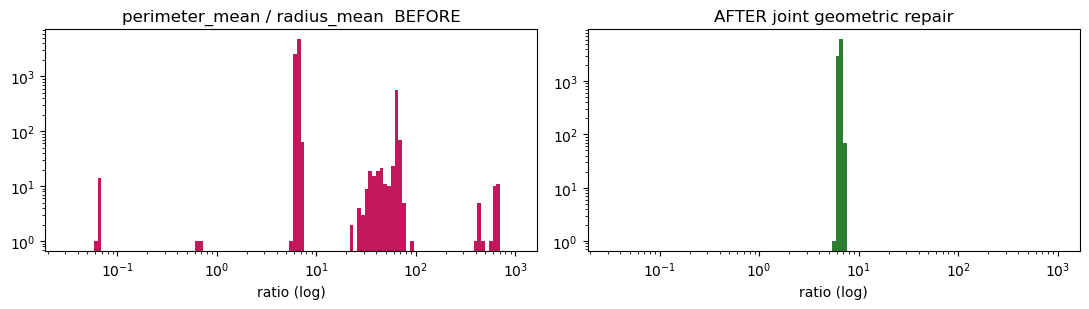

rows with P/R outside [5, 8]: before 10.4%  after 0.00%
missing size cells (radius/perimeter/area mean+worst): before 2654  after 99


In [6]:
before = (num_tr['perimeter_mean'] / num_tr['radius_mean']).where(lambda v: v > 0)
after  = (rep_tr['perimeter_mean'] / rep_tr['radius_mean'])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
bins = np.logspace(-1.5, 3, 120)
ax[0].hist(before.dropna(), bins=bins, color='#c2185b'); ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_title('perimeter_mean / radius_mean  BEFORE'); ax[0].set_xlabel('ratio (log)')
ax[1].hist(after.dropna(), bins=bins, color='#2e7d32'); ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_title('AFTER joint geometric repair'); ax[1].set_xlabel('ratio (log)')
plt.tight_layout(); plt.show()

def share_off(r): return float(((r < 5) | (r > 8)).mean())
EV['pr_bad_before'], EV['pr_bad_after'] = share_off(before.dropna()), share_off(after.dropna())
print(f"rows with P/R outside [5, 8]: before {EV['pr_bad_before']:.1%}  after {EV['pr_bad_after']:.2%}")
print('missing size cells (radius/perimeter/area mean+worst): before',
      int(num_tr[SIZE_COLS].isna().sum().sum()), ' after', int(rep_tr[SIZE_COLS].isna().sum().sum()))
EV['size_missing_before'] = int(num_tr[SIZE_COLS].isna().sum().sum())
EV['size_missing_after'] = int(rep_tr[SIZE_COLS].isna().sum().sum())

## 5. Duplicates and contradictory labels (structural problem 3)

After the IDs are normalised (`ID-842059` = `842059.0` = `84,2059`), 346 patients appear twice in train. Half of these are exact copies and half are re-entries with <1% measurement jitter. Their date, centre, age, sample_ref and code are identical, so each pair is one exam entered twice.

* We **merge** each pair into one record (feature mean) instead of keeping two copies, which would double their weight and leak across CV folds.
* In some pairs the two copies carry **opposite diagnoses**. We **repair** the label instead of deleting the patient. The `biopsy_followup_code` was copied with the row and agrees with the diagnosis in ~97% of uncontested records, so it acts as the tie-breaker (ONC-REF → M, ROUTINE → B). If it says RECHECK we keep both labels at weight 0.5. The code is used **only** for this adjudication and never as a model feature (see section 6).

In [7]:
tr = pd.concat([ctx_tr, rep_tr], axis=1)
te = pd.concat([ctx_te, rep_te], axis=1)
tr['y'] = (tr['diagnosis'] == 'M').astype(int)

g = tr.groupby('patient_id')
dup_ids = g.size()[lambda s: s > 1].index
conflict_ids = g['y'].nunique()[lambda s: s > 1].index
EV['n_dup_patients'] = len(dup_ids); EV['n_conflict'] = len(conflict_ids)
EV['n_exact_dups'] = int(raw_tr.assign(pid=ctx_tr.patient_id).drop(columns='patient_id').duplicated().sum())

uncontested = tr[~tr.patient_id.isin(conflict_ids)]
agree = ((uncontested.code == 'ONC-REF') & (uncontested.y == 1)) | ((uncontested.code == 'ROUTINE') & (uncontested.y == 0))
EV['code_agreement'] = agree[uncontested.code != 'RECHECK'].mean()

rows = []
for pid, d in tr.groupby('patient_id', sort=False):
    base = d.iloc[0].copy(); base[NUM] = d[NUM].mean()
    if d['y'].nunique() == 1:
        base['w'] = 1.0; rows.append(base)
    elif base['code'] in ('ONC-REF', 'ROUTINE'):
        base['y'] = int(base['code'] == 'ONC-REF'); base['w'] = 1.0; rows.append(base)
    else:                                   # RECHECK: genuinely undecidable -> soft label
        for lab in (0, 1):
            b = base.copy(); b['y'] = lab; b['w'] = 0.5; rows.append(b)
train = pd.DataFrame(rows).reset_index(drop=True)
train['y'] = train['y'].astype(int); train['w'] = train['w'].astype(float)
EV['n_conflict_code'] = int(tr[tr.patient_id.isin(conflict_ids)].drop_duplicates('patient_id').code.isin(['ONC-REF', 'ROUTINE']).sum())
EV['n_train_patients'] = train.patient_id.nunique()
print(f"duplicated patients: {EV['n_dup_patients']}  (exact row copies: {EV['n_exact_dups']})")
print(f"pairs with contradictory diagnosis: {EV['n_conflict']}  -> adjudicated by code: {EV['n_conflict_code']}, soft label: {EV['n_conflict'] - EV['n_conflict_code']}")
print(f"code/diagnosis agreement on uncontested records: {EV['code_agreement']:.1%}")
print('training table:', train.shape, '| unique patients:', EV['n_train_patients'])
print('test: rows', len(te), '| unique patients', te.patient_id.nunique(), '| all in sample_submission:',
      set(te.patient_id) == set(sample.patient_id))

duplicated patients: 346  (exact row copies: 173)
pairs with contradictory diagnosis: 50  -> adjudicated by code: 48, soft label: 2
code/diagnosis agreement on uncontested records: 97.7%
training table: (8656, 40) | unique patients: 8654
test: rows 3000 | unique patients 2884 | all in sample_submission: True


## 6. Leakage and junk-column audit: what we drop and why

| column | verdict | evidence |
|---|---|---|
| `biopsy_followup_code` | **drop (target leakage)** | It is an administrative code written *after* the diagnosis: ONC-REF ≈ oncology referral. It nearly reproduces the label (table below). A model that leans on it learns the clerk, not the cells. |
| `notes` | drop | Free text from whoever entered the record. The malignancy rate is flat across all 18 note templates, and the numbers inside (`measured 18,3`, `prior reading 0.114`) are boilerplate. |
| `sample_ref` | drop | Internal lab tracking string. Shared refs across patients are random collisions (9,000 draws from 72,000 codes), and the letter suffix carries no signal. |
| `patient_id`, `exam_date` | not features | Identifiers and dates do not generalise to new patients. Dates are cleaned for the record only. |
| `center` | not a feature | Site C runs ≈7% larger on size measures in both classes (calibration offset, see below). We tested harmonisation and a site flag. Neither helped CV, so the model stays site-agnostic. |

In [8]:
ct = pd.crosstab(tr['code'], tr['diagnosis'], margins=True)
ct['% malignant'] = (ct['M'] / ct['All'] * 100).round(1)
print(ct, '\n')
print('single-feature AUC of the code alone:',
      round(roc_auc_score(tr.y, tr.code.map({'ROUTINE': 0, 'RECHECK': 1, 'ONC-REF': 2})), 3))
EV['code_auc'] = roc_auc_score(tr.y, tr.code.map({'ROUTINE': 0, 'RECHECK': 1, 'ONC-REF': 2}))
EV['onc_ref_pctM'] = ct.loc['ONC-REF', '% malignant']; EV['routine_pctM'] = ct.loc['ROUTINE', '% malignant']

nt = tr.assign(note=tr.notes.fillna('(empty)')).groupby('note').y.agg(['size', 'mean']).query('size >= 30')
EV['notes_rate_min'], EV['notes_rate_max'] = nt['mean'].min(), nt['mean'].max()
print(f"\nnotes: malignant rate across the {len(nt)} note templates (n>=30) ranges {nt['mean'].min():.0%}-{nt['mean'].max():.0%} (overall {tr.y.mean():.0%}) -> no signal")

site = tr.groupby(['center', 'diagnosis'])[['radius_mean', 'area_mean', 'concavity_mean']].median().unstack()
print('\nmedian by site and class (Site C offset in BOTH classes = calibration, not case mix):'); print(site.round(3))
EV['siteC_radius_ratio_B'] = site.loc['Site C', ('radius_mean', 'B')] / site.loc[['Site A', 'Site B'], ('radius_mean', 'B')].mean()

diagnosis     B     M   All  % malignant
code                                    
ONC-REF     135  3314  3449         96.1
RECHECK     110    79   189         41.8
ROUTINE    5249   113  5362          2.1
All        5494  3506  9000         39.0 

single-feature AUC of the code alone: 0.971

notes: malignant rate across the 18 note templates (n>=30) ranges 34%-43% (overall 39%) -> no signal

median by site and class (Site C offset in BOTH classes = calibration, not case mix):
          radius_mean         area_mean          concavity_mean       
diagnosis           B       M         B        M              B      M
center                                                                
Site A         12.340  16.457    470.40  836.700          0.041  0.134
Site B         12.385  16.379    472.90  837.991          0.040  0.135
Site C         13.263  17.146    540.35  912.800          0.062  0.158


## 7. How noisy are the training labels?

Among the patients the model is *most* sure are benign, 3–5% are still labelled M, and among those it is most sure are malignant, 3–6% are labelled B. These rates **level off instead of going to zero** at the extremes, which is what random label flips look like. The 50 duplicate pairs with opposite diagnoses are direct proof that flips exist. For the threshold we use the **smallest** floor we observe. That means the smallest noise correction and therefore the stricter threshold. Two consequences:
1. Cross-validated AUC is capped near 0.93 even for an excellent ranker, so we compare models by CV AUC (it is still monotone in the true AUC) but do not read it as the true performance.
2. Precision measured on noisy labels **understates** precision on a clean answer key. The threshold analysis in section 9 corrects for this.

The OOF scores needed for this are produced in section 8. This cell only defines the estimator.

In [9]:
def flip_floor(y, p, w, frac=0.2):
    o = np.argsort(p); k = int(frac * len(p))
    lo, hi = o[:k], o[-k:]
    e0 = np.average(y[lo], weights=w[lo])            # labelled M among most-benign-looking
    e1 = 1 - np.average(y[hi], weights=w[hi])        # labelled B among most-malignant-looking
    return e0, e1

## 8. Model and validation

* **Features:** the 30 repaired measurements on a log10 scale, plus age. No code, notes, ref, date, site or ID.
* **Models:** L2 logistic regression (median imputation + scaling) and a regularised `HistGradientBoostingClassifier` (handles missing values natively). We use their **average**. LR is stable under covariate shift, and HGB captures non-linearity.
* **Validation:** `StratifiedGroupKFold`, 5 folds × 3 repeats, **grouped by normalised patient_id**. Duplicates were already merged, so the same patient can never sit in both train and validation, including both halves of a soft-labelled pair.

In [10]:
FEATS = NUM + ['age']
def features(d):
    F = np.log10(d[NUM].astype(float).clip(lower=1e-4))
    F['age'] = d['age'].astype(float)
    return F[FEATS]

F_tr, y, w, groups = features(train), train['y'].values, train['w'].values, train['patient_id'].values
F_te = features(te)

MODELS = {
    'LR':  make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LogisticRegression(C=0.3, max_iter=3000)),
    'HGB': HistGradientBoostingClassifier(max_iter=400, learning_rate=0.03, max_leaf_nodes=15,
                                          min_samples_leaf=40, l2_regularization=1.0, random_state=SEED),
}
def fit_w(m, X, yy, ww):
    if hasattr(m, 'steps'): return m.fit(X, yy, **{f'{m.steps[-1][0]}__sample_weight': ww})
    return m.fit(X, yy, sample_weight=ww)

def recall_at_precision(yy, pp, ww, floor=0.90):
    pr, rc, _ = precision_recall_curve(yy, pp, sample_weight=ww)
    return rc[pr >= floor].max()

N_REP = 3
OOF = {k: np.zeros((N_REP, len(y))) for k in MODELS}
for r in range(N_REP):
    for trn, val in StratifiedGroupKFold(5, shuffle=True, random_state=SEED + r).split(F_tr, y, groups):
        assert not set(groups[trn]) & set(groups[val])          # no patient on both sides
        for k, m in MODELS.items():
            OOF[k][r, val] = fit_w(clone(m), F_tr.iloc[trn], y[trn], w[trn]).predict_proba(F_tr.iloc[val])[:, 1]
OOF['ENS'] = (OOF['LR'] + OOF['HGB']) / 2

res = pd.DataFrame({k: {'AUC mean': np.mean([roc_auc_score(y, p, sample_weight=w) for p in P]),
                        'AUC sd':   np.std([roc_auc_score(y, p, sample_weight=w) for p in P]),
                        'recall@P>=0.90 (noisy labels)': np.mean([recall_at_precision(y, p, w) for p in P])}
                    for k, P in OOF.items()}).T
print(res.round(4))
p_oof = OOF['ENS'].mean(0)                                   # averaged over repeats, used below
EV['cv_auc'], EV['cv_auc_sd'] = res.loc['ENS', 'AUC mean'], res.loc['ENS', 'AUC sd']
EV['cv_auc_lr'], EV['cv_auc_hgb'] = res.loc['LR', 'AUC mean'], res.loc['HGB', 'AUC mean']
EV['cv_rec90'] = res.loc['ENS', 'recall@P>=0.90 (noisy labels)']

floors = pd.DataFrame([flip_floor(y, p_oof, w, f) for f in (0.05, 0.1, 0.2, 0.3)], index=['5%', '10%', '20%', '30%'],
                      columns=['labelled M among most benign-looking', 'labelled B among most malignant-looking'])
print(floors.round(3))
e0, e1 = floors.min()          # conservative: the SMALLEST floor -> smallest noise correction -> stricter threshold
EV['flip_e0'], EV['flip_e1'] = e0, e1
EV['floor20_e0'], EV['floor20_e1'] = floors.loc['20%'].values
print(f'flip-rate estimate used for the threshold (conservative): B->M {e0:.3f}, M->B {e1:.3f}')

     AUC mean  AUC sd  recall@P>=0.90 (noisy labels)
LR     0.9284  0.0001                         0.7809
HGB    0.9331  0.0009                         0.8151
ENS    0.9329  0.0004                         0.8147
     labelled M among most benign-looking  labelled B among most malignant-looking
5%                                  0.028                                    0.035
10%                                 0.039                                    0.046
20%                                 0.044                                    0.057
30%                                 0.046                                    0.077
flip-rate estimate used for the threshold (conservative): B->M 0.028, M->B 0.035


### Does the cleaning matter? (ablation on logistic regression, same CV)
Trees are naturally robust to a few absurd cells. A linear model is not, which makes it a clean test of what the repairs buy us.

In [11]:
def quick_cv(F, model, yy, ww, gg):
    p = np.zeros(len(yy))
    for trn, val in StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(F, yy, gg):
        p[val] = fit_w(clone(model), F.iloc[trn], yy[trn], ww[trn]).predict_proba(F.iloc[val])[:, 1]
    return roc_auc_score(yy, p, sample_weight=ww), recall_at_precision(yy, p, ww)

raw_feats = np.log10(num_tr.clip(lower=1e-4)).assign(age=ctx_tr.age.values)   # parsed only, no repairs
rep_feats = features(tr)
gid = ctx_tr.patient_id.values; yy = (ctx_tr.diagnosis == 'M').astype(int).values; ww = np.ones(len(yy))
abl = pd.DataFrame({'parsed only':  quick_cv(raw_feats, MODELS['LR'], yy, ww, gid),
                    'fully repaired': quick_cv(rep_feats, MODELS['LR'], yy, ww, gid)},
                   index=['AUC', 'recall@P>=0.90']).T
print(abl.round(4))
EV['abl_auc_raw'], EV['abl_auc_rep'] = abl.loc['parsed only', 'AUC'], abl.loc['fully repaired', 'AUC']
EV['abl_rec_raw'], EV['abl_rec_rep'] = abl.loc['parsed only', 'recall@P>=0.90'], abl.loc['fully repaired', 'recall@P>=0.90']

                   AUC  recall@P>=0.90
parsed only     0.9038          0.5473
fully repaired  0.9229          0.7613


## 9. Choosing the threshold

The brief warns that the **test set is drawn differently**. For precision, the most dangerous shift is a **lower share of malignant cases**: the same threshold then produces more false alarms per cancer found. Our training prevalence (~39%) looks like a referral clinic. A screening-like population could easily be half that.

For every candidate threshold `t` on the out-of-fold ensemble score we compute:
1. **Noisy precision** at the training prevalence, against the labels exactly as given. This is the worst case if the answer key is as noisy as train.
2. **Noise-corrected precision** at the training prevalence and under a **stress prevalence of 20%**. Out-of-fold scores are calibrated with isotonic regression, the flip rates from section 7 are removed (`q = (r − e0)/(1 − e0 − e1)`), and benign cases are re-weighted to the stress prevalence.

**Rule:** take the lowest threshold (most cancers caught) that satisfies **both** of these:
* stressed, noise-corrected precision ≥ 0.92, i.e. a 2-point margin above the floor;
* noisy precision at training prevalence ≥ 0.90.

Only training out-of-fold predictions are used.

In [12]:
PI_STRESS, TARGET_STRESS, TARGET_NOISY = 0.20, 0.92, 0.90

r_cal = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(p_oof, y, sample_weight=w).predict(p_oof)
q = np.clip((r_cal - e0) / (1 - e0 - e1), 0, 1)            # P(truly malignant | score)
pi_clean = np.average(q, weights=w)

def table(ts):
    out = []
    for t in ts:
        s = p_oof >= t
        tp_n, fp_n = (w * s * y).sum(), (w * s * (1 - y)).sum()
        row = {'t': t, 'flagged %': s.mean() * 100,
               'noisy prec': tp_n / max(tp_n + fp_n, 1e-9), 'noisy recall': tp_n / (w * y).sum()}
        for name, pi in [('train', pi_clean), ('stress', PI_STRESS)]:
            w1, w0 = pi / pi_clean, (1 - pi) / (1 - pi_clean)
            tp, fp = w1 * (w * q * s).sum(), w0 * (w * (1 - q) * s).sum()
            row[f'corr prec @{name}'] = tp / max(tp + fp, 1e-9)
        row['corr recall'] = (w * q * s).sum() / (w * q).sum()
        out.append(row)
    return pd.DataFrame(out)

grid = table(np.round(np.arange(0.30, 0.99, 0.01), 2))
ok = grid[(grid['corr prec @stress'] >= TARGET_STRESS) & (grid['noisy prec'] >= TARGET_NOISY)]
THRESHOLD = float(ok['t'].min())
chosen = grid[grid.t == THRESHOLD].iloc[0]
print(grid[grid.t.isin(np.round(np.arange(0.40, 0.99, 0.05), 2).tolist() + [THRESHOLD])].round(3).to_string(index=False))
print(f'\nchosen threshold = {THRESHOLD:.2f}')

# what one more cancer costs: move from the chosen threshold to 0.10 lower
lo = table([THRESHOLD - 0.10]).iloc[0]
s_hi, s_lo = p_oof >= THRESHOLD, p_oof >= THRESHOLD - 0.10
d_tp = (w * (s_lo & ~s_hi) * q).sum(); d_fp = (w * (s_lo & ~s_hi) * (1 - q)).sum()
stress_fp_ratio = d_fp * ((1 - PI_STRESS) / (1 - pi_clean)) / (d_tp * (PI_STRESS / pi_clean))
print(f'lowering to {THRESHOLD - 0.10:.2f}: +{d_tp:.0f} cancers for +{d_fp:.0f} false alarms in train '
      f'= {d_fp / d_tp:.2f} false alarms per extra cancer at train prevalence, {stress_fp_ratio:.2f} at 20% prevalence; '
      f'stressed precision would drop to {lo["corr prec @stress"]:.3f}')

# bootstrap over patients: how stable is precision at the chosen threshold?
rng = np.random.default_rng(SEED); boot = []
for _ in range(500):
    i = rng.integers(0, len(y), len(y)); s = p_oof[i] >= THRESHOLD
    boot.append((w[i] * s * y[i]).sum() / (w[i] * s).sum())
EV['boot_noisy_prec_p05'] = np.percentile(boot, 5)
print(f'bootstrap 5th percentile of noisy precision at t: {EV["boot_noisy_prec_p05"]:.3f}')

EV.update(threshold=THRESHOLD, pi_stress=PI_STRESS, thr_noisy_prec=chosen['noisy prec'],
          thr_noisy_recall=chosen['noisy recall'], thr_corr_prec_train=chosen['corr prec @train'],
          thr_corr_prec_stress=chosen['corr prec @stress'], thr_corr_recall=chosen['corr recall'],
          fa_per_cancer=d_fp / d_tp, fa_per_cancer_stress=stress_fp_ratio, lower_t=THRESHOLD - 0.10,
          lower_stress_prec=lo['corr prec @stress'], thr_flagged=chosen['flagged %'])
t05 = grid.iloc[(grid.t - 0.50).abs().argmin()]
EV['t05_stress_prec'], EV['t05_noisy_prec'] = t05['corr prec @stress'], t05['noisy prec']

   t  flagged %  noisy prec  noisy recall  corr prec @train  corr prec @stress  corr recall
0.40     39.048       0.864         0.870             0.892              0.768        0.907
0.45     38.124       0.874         0.859             0.903              0.788        0.896
0.50     37.107       0.885         0.847             0.915              0.812        0.884
0.55     36.195       0.894         0.834             0.924              0.830        0.871
0.60     34.970       0.900         0.811             0.931              0.845        0.848
0.65     33.561       0.907         0.785             0.939              0.860        0.820
0.70     32.140       0.913         0.757             0.945              0.874        0.791
0.75     30.407       0.921         0.722             0.953              0.891        0.755
0.80     28.015       0.929         0.671             0.961              0.908        0.701
0.84     25.451       0.933         0.612             0.967              0.921  

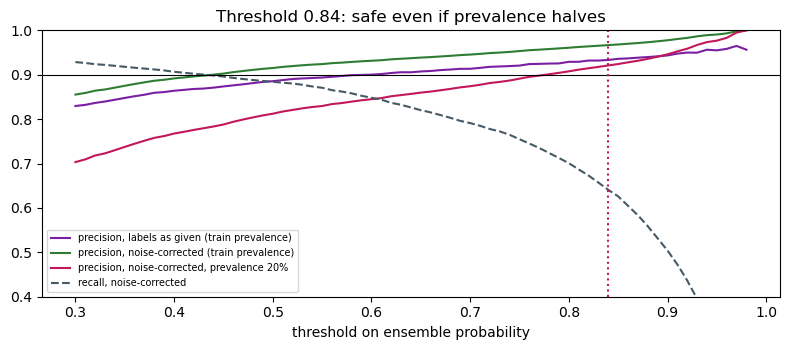

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(grid.t, grid['noisy prec'], label='precision, labels as given (train prevalence)', color='#7b1fa2')
ax.plot(grid.t, grid['corr prec @train'], label='precision, noise-corrected (train prevalence)', color='#2e7d32')
ax.plot(grid.t, grid['corr prec @stress'], label=f'precision, noise-corrected, prevalence {PI_STRESS:.0%}', color='#c2185b')
ax.plot(grid.t, grid['corr recall'], '--', label='recall, noise-corrected', color='#455a64')
ax.axhline(0.90, color='k', lw=0.8); ax.axvline(THRESHOLD, color='#c2185b', ls=':')
ax.set_xlabel('threshold on ensemble probability'); ax.set_ylim(0.4, 1.0); ax.legend(fontsize=7, loc='lower left')
ax.set_title(f'Threshold {THRESHOLD:.2f}: safe even if prevalence halves'); plt.tight_layout(); plt.show()

## 10. Who would this model fail? (subgroup out-of-fold AUC)

In [14]:
sub = pd.DataFrame({'y': y, 'p': p_oof, 'w': w, 'center': train.center.values,
                    'age band': pd.cut(train.age.astype(float), [0, 40, 50, 60, 70, 120], right=False,
                                       labels=['<40', '40-49', '50-59', '60-69', '70+'])})
def sub_auc(d): return pd.Series({'n': len(d), '% M': d.y.mean() * 100, 'AUC': roc_auc_score(d.y, d.p, sample_weight=d.w)})
by_age = sub.groupby('age band').apply(sub_auc); by_site = sub.groupby('center').apply(sub_auc)
print(by_age.round(3)); print(by_site.round(3))
EV['auc_young'], EV['n_young'] = by_age.loc['<40', 'AUC'], int(by_age.loc['<40', 'n'])
EV['auc_siteC'], EV['auc_siteAB'] = by_site.loc['Site C', 'AUC'], by_site.loc[['Site A', 'Site B'], 'AUC'].mean()

               n     % M    AUC
age band                       
<40        432.0  23.611  0.888
40-49     1376.0  29.651  0.920
50-59     2540.0  37.087  0.935
60-69     2545.0  40.943  0.940
70+       1755.0  49.060  0.931
             n     % M    AUC
center                       
Site A  3522.0  38.955  0.935
Site B  3016.0  37.367  0.936
Site C  2118.0  40.604  0.928


## 11. Fit on all training patients, predict the test set, write the submission
Test duplicates (the same patient entered twice) are scored row by row and then averaged per patient. Nothing is fitted on test.

In [15]:
final = {k: fit_w(clone(m), F_tr, y, w) for k, m in MODELS.items()}
te['prob'] = np.mean([final[k].predict_proba(F_te)[:, 1] for k in MODELS], axis=0)

sub_df = (te.groupby('patient_id', sort=False)['prob'].mean().rename('predicted_prob').reset_index())
sub_df['predicted_label'] = np.where(sub_df.predicted_prob >= THRESHOLD, 'M', 'B')
sub_df = sub_df.set_index('patient_id').loc[sample.patient_id].reset_index()     # sample order
sub_df = sub_df[['patient_id', 'predicted_label', 'predicted_prob']]
sub_df['predicted_prob'] = sub_df['predicted_prob'].round(6)

assert len(sub_df) == len(sample) and sub_df.patient_id.is_unique
assert set(sub_df.patient_id) == set(sample.patient_id)
assert sub_df.predicted_label.isin(['M', 'B']).all() and sub_df.predicted_prob.between(0, 1).all()
assert sub_df.notna().all().all()

OUT = f'{TEAM_FILE}_submission_{SUBMISSION_N}.csv'
sub_df.to_csv(OUT, index=False)
EV['n_test_patients'] = len(sub_df)
print(f'wrote {OUT}: {len(sub_df)} patients, {sub_df.predicted_label.eq("M").mean():.1%} flagged M')
sub_df.head()

wrote RelaxTeam_submission_1.csv: 2884 patients, 12.2% flagged M


,patient_id,predicted_label,predicted_prob
0,912511,B,0.066862
1,910569,B,0.040967
2,910709,B,0.083976
3,911138,B,0.021733
4,911095,M,0.875442


## 12. Evidence sheet
Generated from `EV`, so every number on it is one this notebook printed.

In [16]:
R, C = EV['rep_log_tr'], EV['ctx_log_tr']
sheet = f'''# Pink AI evidence sheet | team {TEAM}

**Members:** {', '.join(TEAM_MEMBERS)}

**1. What we cleaned and why (top 5)**
1. Numbers stored as text: {EV['parse_log_tr']['decimal commas']} decimal commas, {EV['parse_log_tr']['thousands separators']} thousands separators, {EV['parse_log_tr']['missing tokens']} missing tokens (?, --, unknown); 4 column names and a 2-line banner.
2. Scale slips: {R['x100 slip']} cells x100 and {R['x1000 slip']} x1000 (factor chosen by the sister columns); {R['tiny float -> 0']} float-junk 1e-11 values set to 0.
3. {R['negative -> rebuilt']} negative areas: abs() still disagreed with the radius, so they were rebuilt, not sign-flipped.
4. {R['rebuilt from geometry']} missing radius/perimeter/area cells rebuilt from geometry (P={EV['cP']:.3f}R, A={EV['cA']:.3f}R^2, learned on train). Missing size cells went from {EV['size_missing_before']} to {EV['size_missing_after']}; no rows dropped.
5. Labels in {EV['n_diag_variants']} raw spellings mapped to M/B. {C['patient_id reformatted']} IDs normalised (ID-, commas, .0, tabs), which is what reveals the duplicates. {C['impossible age -> missing']} ages and {C['impossible calendar date -> missing'] + C['future date -> missing']} dates set missing.

**2. Problems that were not obvious (between columns)**
- **Perimeter and area swapped** in {R['perimeter/area swapped']} rows (P > A is impossible): swapped back. **Radius in cm** in {R['radius cm -> mm']} cells (P/R = 65, not 6.5): x10. Rows with P/R outside [5, 8]: {EV['pr_bad_before']:.1%} -> {EV['pr_bad_after']:.2%}.
- **{EV['n_dup_patients']} patients entered twice, {EV['n_conflict']} with opposite diagnoses.** Merged; {EV['n_conflict_code']} labels repaired by the follow-up code ({EV['code_agreement']:.1%} agreement on uncontested rows), the rest soft-labelled.
- **Training labels are noisy:** {EV['floor20_e0']:.3f} / {EV['floor20_e1']:.3f} of the most confident 20% carry the opposite label. **Site C** reads larger even in benign cases (radius x{EV['siteC_radius_ratio_B']:.3f}).

**3. Columns we dropped, and why**
- **biopsy_followup_code = target leakage:** ONC-REF is {EV['onc_ref_pctM']}% malignant and ROUTINE {EV['routine_pctM']}%; on its own it gives AUC {EV['code_auc']:.3f}. It is written after the diagnosis, so it does not exist at prediction time.
- notes (malignant rate {EV['notes_rate_min']:.0%}-{EV['notes_rate_max']:.0%} in every template), sample_ref (random lab string), IDs and dates: no signal. center: a calibration risk.

**4. How we validated**
- StratifiedGroupKFold, 5 folds x 3 repeats, grouped by the *normalised* patient_id after merging duplicates. The code asserts that no patient lands in both train and validation. Repair parameters are learned on train only.
- Ensemble of logistic regression and gradient boosting: CV AUC {EV['cv_auc']:.4f} +/- {EV['cv_auc_sd']:.4f}, scored against noisy labels. Repairs raise the linear model from AUC {EV['abl_auc_raw']:.4f} to {EV['abl_auc_rep']:.4f} and recall@P90 from {EV['abl_rec_raw']:.4f} to {EV['abl_rec_rep']:.4f}.

**5. Our threshold, and why**
- **t = {EV['threshold']:.2f}.** It is the lowest t where precision stays >= 0.92 after removing label noise *and* halving prevalence to {EV['pi_stress']:.0%} (the brief warns that test is drawn differently), and where precision on the labels as given is >= 0.90 ({EV['thr_noisy_prec']:.3f}; bootstrap 5th percentile {EV['boot_noisy_prec_p05']:.3f}).
- Expected precision {EV['thr_corr_prec_stress']:.3f} under that stress, recall {EV['thr_corr_recall']:.3f}. The default t = 0.5 would give only {EV['t05_stress_prec']:.3f}.
- Cost: dropping t by 0.10 costs {EV['fa_per_cancer']:.2f} false alarms per extra cancer at the training mix ({EV['fa_per_cancer_stress']:.2f} at 20% prevalence) and breaks the stressed floor ({EV['lower_stress_prec']:.3f}).

**6. What would break this model**
- Younger women (<40: CV AUC {EV['auc_young']:.3f} vs {EV['cv_auc']:.4f} overall), a new site or scanner with its own calibration, or an unseen unit convention.
- A population with far fewer than 20% cancers (screening): precision would drop below 0.90, so the threshold must be re-set.
- **Never** a stand-alone diagnosis and never a reason to skip biopsy. It is a triage aid on top of a pathologist.

**AI assistants:** Claude Code helped with exploratory checks, drafting the cleaning and validation code, and stress-testing the threshold logic. The team reviewed and can explain every decision.
'''
with open('evidence_sheet.md', 'w', encoding='utf-8') as f:
    f.write(sheet)
print(sheet)

# Pink AI evidence sheet | team Relax Team

**Members:** Yousef Shabib, Ahmad Irshaid, Sarah Alzaro

**1. What we cleaned and why (top 5)**
1. Numbers stored as text: 9900 decimal commas, 1389 thousands separators, 3256 missing tokens (?, --, unknown); 4 column names and a 2-line banner.
2. Scale slips: 610 cells x100 and 613 x1000 (factor chosen by the sister columns); 409 float-junk 1e-11 values set to 0.
3. 40 negative areas: abs() still disagreed with the radius, so they were rebuilt, not sign-flipped.
4. 2601 missing radius/perimeter/area cells rebuilt from geometry (P=6.479R, A=3.080R^2, learned on train). Missing size cells went from 2654 to 99; no rows dropped.
5. Labels in 67 raw spellings mapped to M/B. 4328 IDs normalised (ID-, commas, .0, tabs), which is what reveals the duplicates. 9 ages and 79 dates set missing.

**2. Problems that were not obvious (between columns)**
- **Perimeter and area swapped** in 158 rows (P > A is impossible): swapped back. **Radius in cm** in 13